### EESI Toy Model: Unit Gaussian → Scaled Beta Distribution

A minimal, self-contained illustration of the `eesi` interpolant framework in 2D.

We learn a generative map from a simple **base** distribution to a more complex
**target**:

- **Base** `p_0(x,y)`: a single Gaussian, `N(0, I)` (unit variance, zero covariance).
- **Target** `p_1(x,y)`: a rotated product of scaled Beta distributions, `4*(Beta[3/2,3/2](z)-1/2)` and `(Beta[2,2](w)-1/2)` where `z/w = (y +/- x)/sqrt(2)`.

The `EESI` model trains a drift field `b(t, x, y)` and a score field `s(t, x, y)` along the stochastic interpolant.

$$x_t = (1-t)\,x_0 + t \,x_1 + a\sqrt{t(1-t)}\,z,\qquad z\sim N(0, I), \qquad a = 0.2$$

then estimates the entropy difference using a variety of strategies:
- integrate the learned probability-flow ODE (or reverse-time SDE) from
`t=0` (base) to `t=1` (target), acculumating entropy as either `b * s` or `div(b)` along the paths. 
- directly sample the interpolant from the data, taking the average of `b * s` or `div(b)`

This notebook covers **setup & instantiation**,
the **training loop**, **sampling**, and **contour plotting**.

In [124]:
# --- imports & environment ---
import sys
import pathlib

import torch
import numpy as np
import scipy.ndimage
import matplotlib.pyplot as plt
from torch.distributions import MultivariateNormal, Beta
from torch import tensor,Tensor

# Make the `eesi` package importable whether the notebook is launched from the
# repo root or from this experiments/ folder (no install required).
_cwd = pathlib.Path.cwd()
for _root in (_cwd, _cwd.parent, _cwd.parent.parent):
    if (_root / "eesi" / "__init__.py").exists():
        sys.path.insert(0, str(_root))
        break
from eesi import EESI, TimeMLP

%matplotlib inline
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### 1. Base and target distributions

The base is standard normal, `N(0, I)`. The target is a two-dimensional rotated anisotropic Beta distribution.

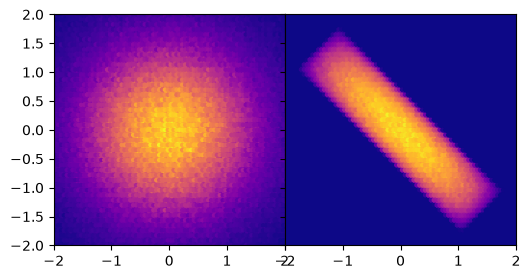

In [126]:
# --- base: single 2D Gaussian, unit variance, zero covariance ---
base = MultivariateNormal(torch.zeros(2, device=device), torch.eye(2, device=device))

# --- target: shifted and scaled Beta distribution (looks like a Wigner semicircle)
target_z = Beta(tensor([1.5], device=device), tensor([1.5], device=device))
scale_z = 2
target_w = Beta(tensor([2], device=device), tensor([2], device=device))
scale_w = 0.5
def sample_target(_size = torch.Size()) -> Tensor:
    z = 2.0*scale_z*(target_z.sample(_size)-0.5)
    w = 2.0*scale_w*(target_z.sample(_size)-0.5)
    x = (w - z)/np.sqrt(2.0)
    y = (w + z)/np.sqrt(2.0)
    return torch.cat([x,y],dim=-1)

def log_prod_target(r : Tensor) -> Tensor:

    w = (r[:,0] + r[:,1]) / np.sqrt(2.0)
    w = w/(2.0*scale_w) + 0.5
    w.clamp_(1e-5,1-1e-5)
    lpw = target_w.log_prob(w) - np.log(2.0*scale_w)

    z = (r[:,1] - r[:,0]) / np.sqrt(2.0)
    z = z/(2.0*scale_z) + 0.5
    z.clamp_(1e-5,1-1e-5)
    lpz = target_z.log_prob(z) - np.log(2.0*scale_z)

    return lpw + lpz

# Sanity check: draw and scatter samples from each distribution.
torch.manual_seed(1)
x0_vis = base.sample((1_000_000,)).cpu()
x1_vis = sample_target((1_000_000,)).cpu()

fig, axs = plt.subplots(1, 2, figsize=(6, 3), sharey=True, sharex=True)

axs[0].hexbin(x0_vis[:,0],x0_vis[:,1],gridsize=120,
                extent=[-3,3,-3,3],cmap='plasma')
axs[1].hexbin(x1_vis[:,0],x1_vis[:,1],gridsize=120,
                extent=[-3,3,-3,3],cmap='plasma')
axs[0].set_xlim(-2,2)
axs[0].set_ylim(-2,2)
axs[0].set_aspect('equal')
axs[1].set_aspect('equal')

plt.subplots_adjust(wspace=-.01)
plt.show()

### 2. Model & sampler setup

`EESI` wraps two `TimeMLP` fields — the drift `net_b` and the score `net_s`.

- `path="linear"` uses the basic interpolant `x_t = (1 - t) x_0 + t x_1`.
- `gamma="sqrt"` is the latent-noise schedule `γ(t) = sqrt( t*(1-t) )`.

In both cases, antithetic sampling is used to reduce variance assosciated with
the endpoints `γ(0) = γ(1) = 0`. This amounts to sample `+/- z` for each sample.

In [96]:
net_b = TimeMLP(d=2, hidden=16, n_layers=4, activation="tanh")
net_s = TimeMLP(d=2, hidden=16, n_layers=4, activation="tanh")

model = EESI(
    net_b, net_s,
    d=2,
    path="linear",
    gamma="sqrt",
    gamma_scale=0.2
).to(device)

### 3. Training loop
For demonstrating the effect of limited data, we sample `x1` just once
as we assume this is difficult to sample.
Each iteration then draws a fresh batch from the base `x_0`, forms the interpolant
internally, and returns the drift/score losses. We minimise their sum.

In [98]:
# training run
def train(model,opt,x1,batch,n_iters):
    hist_b, hist_s = [], []
    for it in range(n_iters):
        x0 = base.sample((batch,))
        losses = model.loss(x1, x0)          # {"b": drift loss, "s": score loss}
        loss = losses["b"] + losses["s"]

        opt.zero_grad()
        loss.backward()
        opt.step()

        hist_b.append(losses["b"].item())
        hist_s.append(losses["s"].item())
        if it % 5000 == 0:
            print(f"iter {it:4d}  loss_b={hist_b[-1]:+.3f}  loss_s={hist_s[-1]:+.3f}")
    print(f"iter {it:4d}  loss_b={hist_b[-1]:+.3f}  loss_s={hist_s[-1]:+.3f}")
    return model, hist_b, hist_s


In [ ]:
torch.manual_seed(1)

batch = 10_000
x1 = sample_target((batch,))

hist_b_tot = []
hist_s_tot = []

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
model, hist_b, hist_s = train(model,opt,x1,batch,50_000)
hist_b_tot += hist_b
hist_s_tot += hist_s


iter    0  loss_b=+0.005  loss_s=+0.009
iter 5000  loss_b=-0.521  loss_s=-4.481
iter 10000  loss_b=-0.551  loss_s=-4.361
iter 15000  loss_b=-0.535  loss_s=-4.608
iter 20000  loss_b=-0.540  loss_s=-4.737
iter 25000  loss_b=-0.557  loss_s=-4.158
iter 30000  loss_b=-0.560  loss_s=-4.540
iter 35000  loss_b=-0.542  loss_s=-4.373
iter 40000  loss_b=-0.545  loss_s=-5.048
iter 45000  loss_b=-0.544  loss_s=-5.105
iter 49999  loss_b=-0.534  loss_s=-4.563


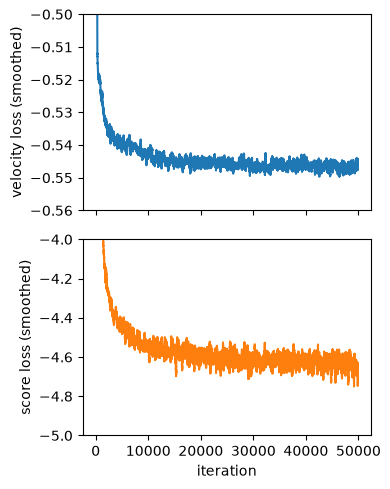

In [128]:
# Training curves (smoothed).
def smooth(v, k=100):
    v = np.asarray(v)
    if len(v) < k:
        return v
    return np.convolve(v, np.ones(k) / k, mode="valid")

fig, ax = plt.subplots(2,1,sharex=True,figsize=(4,5))
ax[0].plot(smooth(hist_b_tot),'-C0')
ax[0].set_ylabel("velocity loss (smoothed)")
ax[1].plot(smooth(hist_s_tot),'-C1')
ax[1].set_xlabel("iteration") 
ax[1].set_ylabel("score loss (smoothed)")
ax[1].set_ylim(-5,-4)
ax[0].set_ylim(-0.56,-0.5)
plt.tight_layout()
plt.show()

### 4. Sampling

Map base samples to the target with the model's built-in sampler. `model.sample` integrates the reverse-time **SDE** with Euler–Maruyama, using both the drift `b` and the learned score `s` (diffusion `eps`). If `eps == 0`, then the evolution reduces to an **ODE** which is integrated with Heun's method.

In [129]:
# Draw base samples and push them through the model samplers.
torch.manual_seed(1)
batch = 100000
x1 = sample_target((batch,)) # for comparison

torch.seed()
x0 = base.sample((batch,))

# probability-flow ODE (drift only)
gen_ode = model.sample(x0, n_steps=100)        

# reverse-time SDE (drift + score)
gen_sde = model.sample(x0, n_steps=200, eps=0.1)    

# How well do generated samples match the target? (mean log-density)
ref = log_prod_target(x1).mean()
base_ref = base.log_prob(x0).mean()
print(f"mean log-prob — ODE sampler : {log_prod_target(gen_ode).mean():+.3f}")
print(f"mean log-prob — SDE sampler : {log_prod_target(gen_sde).mean():+.3f}")
print(f"mean log-prob — true target : {ref:+.3f}")
print(f"mean log-prob — base        : {base_ref:+.3f}")
print(f"estimated entropy change    : {-ref + base_ref:+.3f}")

mean log-prob — ODE sampler : -1.361
mean log-prob — SDE sampler : -1.343
mean log-prob — true target : -1.318
mean log-prob — base        : -2.834
estimated entropy change    : -1.515


### 5. Entropy along the paths

The trajectory-returning `*_entropy_traj` samplers augment every path with the
running integral

$$\Delta\text{S}(t) = -\int_0^t b(x_{t'}, t')\cdot s(x_{t'}, t')\,dt',$$

an estimate of how the (differential) entropy of the flowing density changes as
samples move from base to target. With `sample_ode_entropy_traj` we get the full
`ΔS(t)` curve for every sample at once, so we can plot many paths together
and read off the ensemble-mean entropy change.

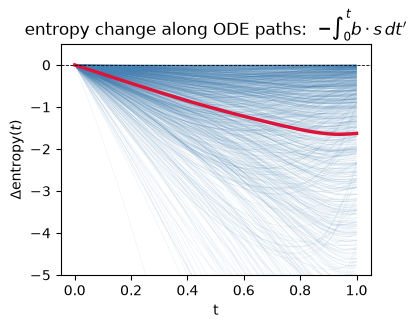

mean ΔS(1)  (base → target): -1.55037


In [132]:
# Trace the running entropy change along many ODE paths.
torch.manual_seed(1)
batch = 10000
x1 = sample_target((batch,))

torch.manual_seed(3)
means =  []
for k in range(20):
    x0 = base.sample((batch,))
    traj, ent_traj, ts = model.sample(x0, eps=0, n_steps=100, 
                                        return_traj=True, entropy='dot')
    means.append(ent_traj[-1,:].mean().cpu().numpy())

ts_c = ts.cpu().numpy()[:1000]
ent_c = ent_traj.cpu().numpy()[:,:1000]         # [n_steps+1, B]

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(ts_c, ent_c, c="steelblue", lw=0.4, alpha=0.12)                  # individual paths
ax.plot(ts_c, ent_c.mean(axis=1), c="crimson", lw=2.5, label="ensemble mean")
ax.axhline(0.0, c="k", lw=0.6, ls="--")
ax.set_xlabel("t"); ax.set_ylabel(r"$\Delta$entropy$(t)$")
ax.set_title(r"entropy change along ODE paths:  $-\int_0^t b\cdot s\,dt'$")
#ax.legend()
ax.set_ylim(-5,0.5)
plt.show()

print(f"mean ΔS(1)  (base → target): {np.mean(means):+.5f}")

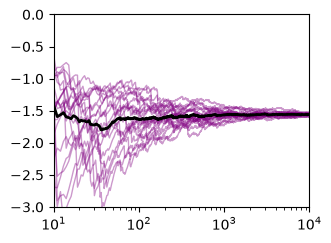

-1.5595126
0.01891934


In [133]:
# Examine convergence based on number of trajectories simulated
vals = []
torch.manual_seed(4)
batch = 10_000

plt.figure(figsize=(3.3,2.5))

mom = []
for k in range(20):
    x0 = base.sample((batch,))
    x,ent = model.sample(x0, eps=0, n_steps=100, entropy='dot')
    ent_cpu = ent.cpu().numpy()
    vals.append(np.mean(ent_cpu))
    #print(np.mean(ent_cpu))
    mean = np.cumsum(ent_cpu)/np.arange(1,batch+1)
    mom.append(mean)
    plt.plot(np.arange(1,batch+1),mean,'-',color='purple',alpha=0.4,lw=1)
mom = np.mean(mom,axis=0)
plt.plot(np.arange(1,batch+1),mom,'-',color='k',lw=2)
#plt.yscale('log')
plt.xscale('log')
plt.xlim(10,10000)
plt.ylim(-3,0)
plt.show()
print(np.mean(vals))
print(np.std(vals))


### 6. Generation-Free Entropy Estimate

In [134]:
torch.manual_seed(1)
batch = 10000
x1 = sample_target((batch,))

torch.manual_seed(7)
means = []
for n in range(1000):
    x0 = base.sample((batch,))
    ent = model.entropy_estimate(x1,x0,'dot') # b*s formulation
    means.append(ent.mean().cpu().numpy())
print(np.mean(means))
print(np.std(means))

-1.5530173
0.027506694


In [135]:

means = []
for n in range(1000):
    x0 = base.sample((batch,))
    ent = model.entropy_estimate(x1,x0,'div') # div(b) formulation
    means.append(ent.mean().cpu().numpy())
print(np.mean(means))
print(np.std(means))

-1.5516031
0.011639876
